CSE425 Project

**Goal:** Build a deep unsupervised model capable of generating novel music pieces across
multiple genres such as Classical, Jazz, Rock, Pop, and Electronic.

**Task 1 & 2 only**

v9.5.1

### Mount drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Imports

In [2]:
# Install dependencies in notebook environment
%pip install -q numpy torch pretty_midi matplotlib tqdm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 103.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 5.5 MB/s eta 0:00:00


In [3]:
# Enable CUDA_LAUNCH_BLOCKING for detailed error messages
import os
import glob
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'
os.environ['TORCH_USE_CUDA_DSA'] = '1'     # enables device‑side assertions

In [4]:
import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, random_split
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.amp import autocast, GradScaler

In [41]:
from pathlib import Path
import re
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pretty_midi
from tqdm.auto import tqdm
import pickle
from collections import defaultdict, Counter

In [6]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

### Config

In [7]:
#Flag
RUN_AE = True
RUN_VAE = True

# Env setup
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# For training
BATCH_SIZE = 64 #Don't decay the learning rate, increase the batch size.

# Tokenization
STEPS_PER_BAR = 16          # Counts the steps relative to the music note.
WINDOW_SIZE = 128           # tokens per training window
PITCH_RANGE = (21, 108)     # Restrict to 88 for piano range
VELOCITY_BINS = 32
NUM_PITCHES  = PITCH_RANGE[1] - PITCH_RANGE[0] + 1  # 88 for piano roll
DURATION_BINS = 8                     # 8 bins for duration (1 step = 1/16 bar)
DURATION_OFFSET = NUM_PITCHES + VELOCITY_BINS + 4   # after specials + pitch + velocity

# Genres supported
GENRES = ["classical", "jazz", "rock", "pop", "electronic"]
NUM_GENRES = len(GENRES)
GENRE_TO_IDX = {g: i for i, g in enumerate(GENRES)}

# Vocabulary size  (pitch + velocity_bins + special tokens)
# VOCAB_SIZE = NUM_PITCHES + VELOCITY_BINS + 4   # +4: PAD, BOS, EOS, REST
VOCAB_SIZE = NUM_PITCHES + VELOCITY_BINS + DURATION_BINS + 4

# Special token IDs
PAD_TOKEN = 0
BOS_TOKEN = 1
EOS_TOKEN = 2
REST_TOKEN = 3

# AE Config
AE_INPUT_DIM: int = 128
AE_HIDDEN_DIM: int = 512
AE_LATENT_DIM: int = 128
AE_NUM_LAYERS: int = 2
AE_DROPOUT: int = 0.2
AE_LEARNING_RATE: int = 1e-3
AE_EPOCHS: int = 25

# VAE Config
VAE_INPUT_DIM: int = 128
VAE_HIDDEN_DIM: int = 256
VAE_LATENT_DIM: int = 128
VAE_NUM_LAYERS: int = 2
VAE_DROPOUT: float = 0.2
VAE_LR: float = 1e-3
VAE_BETA: float = 4.0
VAE_EPOCHS: int = 30

def get_device() -> torch.device:
	return torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Directories
PROJECT_ROOT = Path("/content/drive/MyDrive/CSE425")

RAW_MIDI_DIR: Path = PROJECT_ROOT / "data" / "raw_midi"
PROCESSED_DIR: Path = PROJECT_ROOT / "data" / "processed"
SPLIT_DIR: Path = PROJECT_ROOT / "data" / "train_test_split"

OUTPUTS_DIR: Path = PROJECT_ROOT / "outputs"
PLOTS_DIR: Path = PROJECT_ROOT / "outputs" / "plots"
GENERATED_MIDI_DIR: Path = PROJECT_ROOT / "outputs" / "generated_midis"
CHECKPOINTS_DIR: Path = PROJECT_ROOT / "outputs" / "checkpoints"

def ensure_output_dirs():
    PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
    SPLIT_DIR.mkdir(parents=True, exist_ok=True)
    OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)
    PLOTS_DIR.mkdir(parents=True, exist_ok=True)
    GENERATED_MIDI_DIR.mkdir(parents=True, exist_ok=True)
    CHECKPOINTS_DIR.mkdir(parents=True, exist_ok=True)

ensure_output_dirs()

### EDA

Total MIDI files found: 19142


Scanning MIDI:   0%|          | 0/500 [00:00<?, ?it/s]

Error with /content/drive/MyDrive/CSE425/data/raw_midi/rock/Don't Stop 'Til You Get Enough.mid: Message length 2093056 exceeds maximum length 1000000


/usr/local/lib/python3.12/dist-packages/pretty_midi/pretty_midi.py:122: RuntimeWarning: Tempo, Key or Time signature change events found on non-zero tracks.  This is not a valid type 0 or type 1 MIDI file.  Tempo, Key or Time Signature may be wrong.
  warnings.warn(


Error with /content/drive/MyDrive/CSE425/data/raw_midi/rock/Hairspray Queen.1.mid: data byte must be in range 0..127
Error with /content/drive/MyDrive/CSE425/data/raw_midi/electronic/Love is in the Air.3.mid: data byte must be in range 0..127
Error with /content/drive/MyDrive/CSE425/data/raw_midi/rock/Peggy Sue.1.mid: 
Error with /content/drive/MyDrive/CSE425/data/raw_midi/rock/tourette's.1.mid: data byte must be in range 0..127
Error with /content/drive/MyDrive/CSE425/data/raw_midi/rock/You Are Not Alone.mid: data byte must be in range 0..127
Error with /content/drive/MyDrive/CSE425/data/raw_midi/electronic/Right Now.1.mid: data byte must be in range 0..127

Analysed 493 files.
Duration – min: 0.0m, max: 41.0m, mean: 4.3m
Note count – min: 7, max: 23469, mean: 4793
Velocity – min: 1, max: 127, mean: 86.3
Piano‑roll sparsity (fraction zero): mean = 96.06%
  Saved: /content/drive/MyDrive/CSE425/outputs/plots/eda_duration.png
  Saved: /content/drive/MyDrive/CSE425/outputs/plots/eda_note_

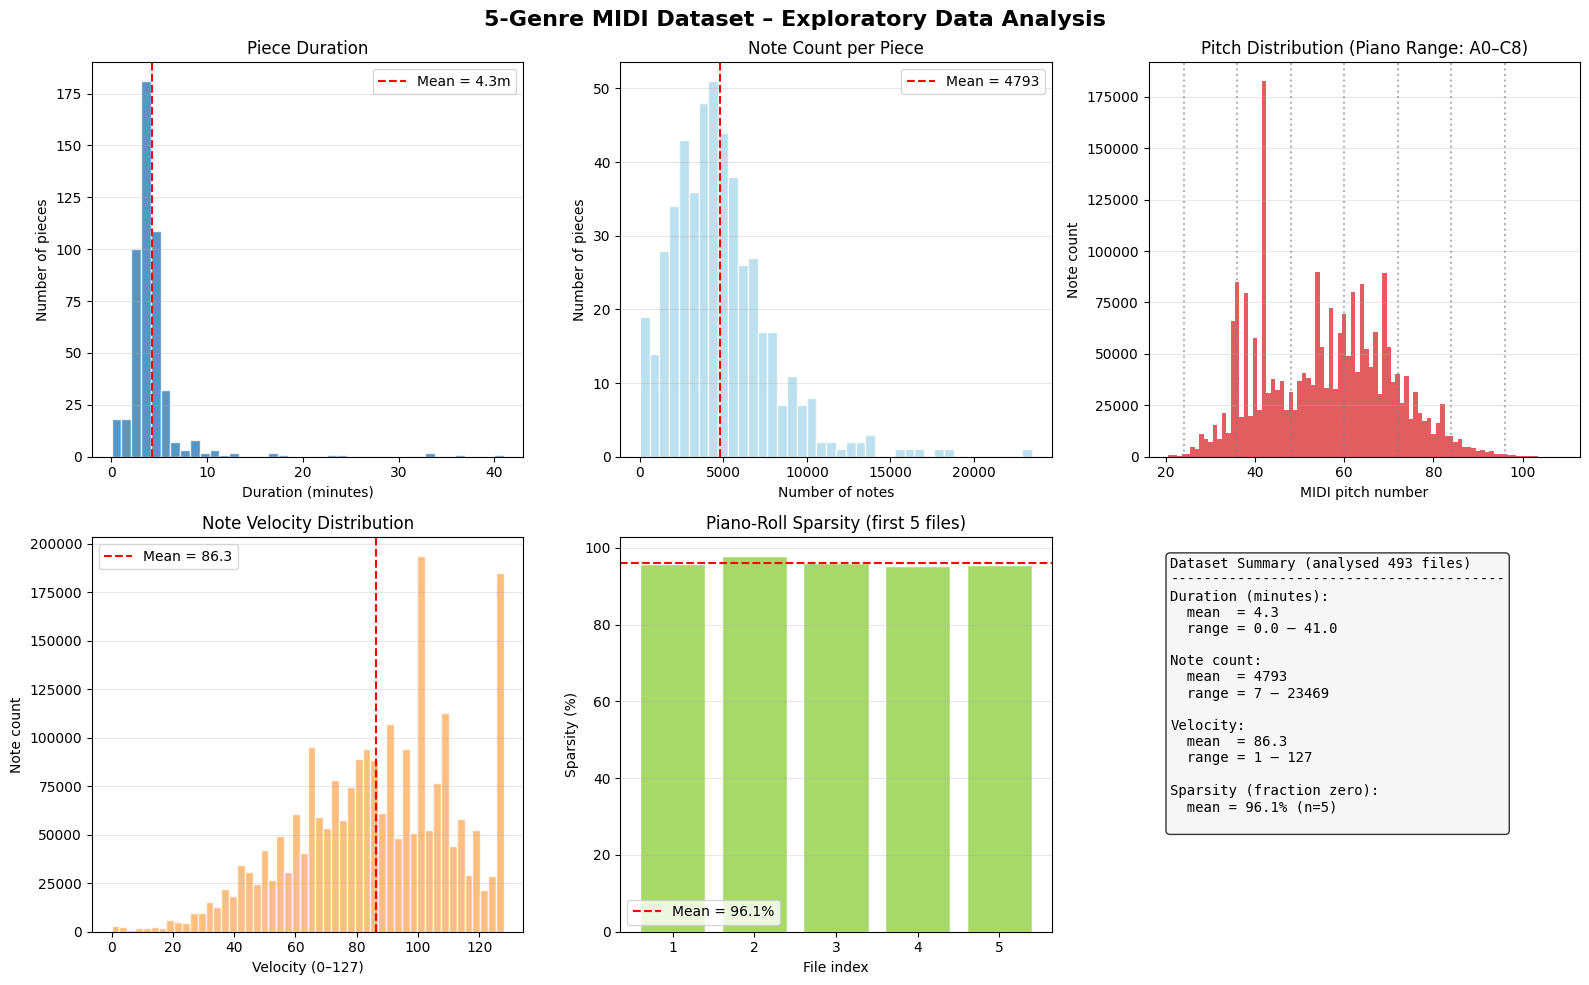


Combined plot saved as '/content/drive/MyDrive/CSE425/outputs/plots/eda_5genres.png'


In [9]:
"""
EDA Pipeline for 5‑Genre MIDI Dataset (MAESTRO, Groove, Lakh subset)
--------------------------------------------------------------------
Computes and plots:
  - Piece duration histogram
  - Note count per piece
  - Pitch distribution (restricted to piano range 21–108)
  - Velocity distribution
  - Piano‑roll sparsity (fraction of non‑zero cells)
Saves individual plots and a combined figure.
"""
# Ensure output directory exists
os.makedirs(PLOTS_DIR, exist_ok=True)

# Collect all MIDI files recursively
midi_files = []
for genre in GENRES:
    genre_path = os.path.join(RAW_MIDI_DIR, genre)
    if not os.path.isdir(genre_path):
        print(f"Warning: {genre_path} does not exist – skipping {genre}")
        continue
    for ext in ["*.mid", "*.midi"]:
        midi_files.extend(glob.glob(os.path.join(genre_path, "**", ext), recursive=True))

print(f"Total MIDI files found: {len(midi_files)}")

# Sample parameters
SAMPLE_SIZE = 500          # number of files for note/pitch/velocity analysis
SPARSITY_SAMPLE = 5        # files for full piano‑roll sparsity (expensive)

if len(midi_files) > SAMPLE_SIZE:
    sample_paths = np.random.choice(midi_files, size=SAMPLE_SIZE, replace=False)
else:
    sample_paths = midi_files

# Collect statistics
durations = []        # duration in seconds
note_counts = []
pitch_counts = np.zeros(128, dtype=np.int64)   # full 0-127, but we'll restrict later
velocity_vals = []
sparsity_vals = []    # fraction of zero cells

for i, path in enumerate(tqdm(sample_paths, desc="Scanning MIDI")):
    try:
        midi = pretty_midi.PrettyMIDI(path)
        notes = [note for inst in midi.instruments for note in inst.notes]

        # Duration (end time of last note, or midi.get_end_time())
        dur = max((n.end for n in notes), default=0.0)
        durations.append(dur)

        # Note count
        note_counts.append(len(notes))

        # Pitch histogram (only notes within piano range 21-108)
        for n in notes:
            if 21 <= n.pitch <= 108:
                pitch_counts[n.pitch] += 1
            # velocities collected regardless of pitch range
            velocity_vals.append(n.velocity)

        # Sparsity (only for first SPARSITY_SAMPLE files across the whole set)
        if i < SPARSITY_SAMPLE:
            fs = 50   # frames per second (20 ms resolution)
            roll = midi.get_piano_roll(fs=fs)        # shape (128, T)
            nonzero_frac = np.count_nonzero(roll) / roll.size
            sparsity_vals.append(1.0 - nonzero_frac)   # fraction zeros
    except Exception as e:
        print(f"Error with {path}: {e}")
        continue

print(f"\nAnalysed {len(durations)} files.")
print(f"Duration – min: {min(durations)/60:.1f}m, max: {max(durations)/60:.1f}m, mean: {np.mean(durations)/60:.1f}m")
print(f"Note count – min: {min(note_counts)}, max: {max(note_counts)}, mean: {np.mean(note_counts):.0f}")
print(f"Velocity – min: {min(velocity_vals)}, max: {max(velocity_vals)}, mean: {np.mean(velocity_vals):.1f}")
if sparsity_vals:
    print(f"Piano‑roll sparsity (fraction zero): mean = {np.mean(sparsity_vals)*100:.2f}%")

# ---------- Helper to save individual figures ----------
def save_figure(fig, filename):
    path = os.path.join(PLOTS_DIR, filename)
    fig.savefig(path, dpi=150, bbox_inches="tight")
    plt.close(fig)
    print(f"  Saved: {path}")

# ---------- 1. Duration histogram ----------
fig1, ax = plt.subplots(figsize=(8, 5))
durations_min = [d/60 for d in durations]
ax.hist(durations_min, bins=40, color='#2c7bb6', edgecolor='white', alpha=0.8)
ax.set_xlabel("Duration (minutes)")
ax.set_ylabel("Number of pieces")
ax.set_title("Piece Duration")
ax.axvline(np.mean(durations_min), color='red', linestyle='--', label=f"Mean = {np.mean(durations_min):.1f}m")
ax.legend()
ax.grid(alpha=0.3, axis='y')
save_figure(fig1, "eda_duration.png")

# ---------- 2. Note count per piece ----------
fig2, ax = plt.subplots(figsize=(8, 5))
ax.hist(note_counts, bins=40, color='#abd9e9', edgecolor='white', alpha=0.8)
ax.set_xlabel("Number of notes")
ax.set_ylabel("Number of pieces")
ax.set_title("Note Count per Piece")
ax.axvline(np.mean(note_counts), color='red', linestyle='--', label=f"Mean = {np.mean(note_counts):.0f}")
ax.legend()
ax.grid(alpha=0.3, axis='y')
save_figure(fig2, "eda_note_count.png")

# ---------- 3. Pitch distribution (piano range 21-108) ----------
fig3, ax = plt.subplots(figsize=(12, 5))
piano_range = range(21, 109)
pitch_counts_88 = pitch_counts[21:109]
ax.bar(piano_range, pitch_counts_88, width=1.0, color='#d7191c', alpha=0.7)
ax.set_xlabel("MIDI pitch number")
ax.set_ylabel("Note count")
ax.set_title("Pitch Distribution (Piano Range: A0–C8)")
# Mark octave Cs
for c in [24, 36, 48, 60, 72, 84, 96]:
    ax.axvline(c, color='gray', linestyle=':', alpha=0.6)
ax.grid(alpha=0.3, axis='y')
save_figure(fig3, "eda_pitch.png")

# ---------- 4. Velocity distribution ----------
fig4, ax = plt.subplots(figsize=(8, 5))
ax.hist(velocity_vals, bins=50, range=(0,128), color='#fdae61', edgecolor='white', alpha=0.8)
ax.set_xlabel("Velocity (0–127)")
ax.set_ylabel("Note count")
ax.set_title("Note Velocity Distribution")
ax.axvline(np.mean(velocity_vals), color='red', linestyle='--', label=f"Mean = {np.mean(velocity_vals):.1f}")
ax.legend()
ax.grid(alpha=0.3, axis='y')
save_figure(fig4, "eda_velocity.png")

# ---------- 5. Sparsity bar chart (if data exists) ----------
if sparsity_vals:
    fig5, ax = plt.subplots(figsize=(8, 5))
    ax.bar(range(1, len(sparsity_vals)+1), [s*100 for s in sparsity_vals], color='#a6d96a', edgecolor='white')
    ax.set_xlabel("File index")
    ax.set_ylabel("Sparsity (%)")
    ax.set_title(f"Piano‑Roll Sparsity (first {SPARSITY_SAMPLE} files)")
    ax.axhline(np.mean(sparsity_vals)*100, color='red', linestyle='--', label=f"Mean = {np.mean(sparsity_vals)*100:.1f}%")
    ax.legend()
    ax.grid(alpha=0.3, axis='y')
    save_figure(fig5, "eda_sparsity.png")
else:
    print("  No sparsity data – skipping sparsity plot.")

# ---------- 6. (Optional) Summary text panel ----------
fig6, ax = plt.subplots(figsize=(8, 5))
ax.axis('off')
summary_text = f"""Dataset Summary (analysed {len(durations)} files)
----------------------------------------
Duration (minutes):
  mean  = {np.mean(durations_min):.1f}
  range = {min(durations_min):.1f} – {max(durations_min):.1f}

Note count:
  mean  = {np.mean(note_counts):.0f}
  range = {min(note_counts)} – {max(note_counts)}

Velocity:
  mean  = {np.mean(velocity_vals):.1f}
  range = {min(velocity_vals)} – {max(velocity_vals)}

Sparsity (fraction zero):
  mean = {np.mean(sparsity_vals)*100:.1f}% (n={len(sparsity_vals)})
"""
ax.text(0.05, 0.95, summary_text, transform=ax.transAxes, fontsize=12, verticalalignment='top',
        fontfamily='monospace', bbox=dict(boxstyle='round', facecolor='#f5f5f5', alpha=0.8))
save_figure(fig6, "eda_summary.png")

# ---------- 7. Combined figure (original 6‑panel layout) ----------
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("5‑Genre MIDI Dataset – Exploratory Data Analysis", fontsize=16, fontweight='bold')

# (a) Duration histogram
ax = axes[0,0]
ax.hist(durations_min, bins=40, color='#2c7bb6', edgecolor='white', alpha=0.8)
ax.set_xlabel("Duration (minutes)")
ax.set_ylabel("Number of pieces")
ax.set_title("Piece Duration")
ax.axvline(np.mean(durations_min), color='red', linestyle='--', label=f"Mean = {np.mean(durations_min):.1f}m")
ax.legend()
ax.grid(alpha=0.3, axis='y')

# (b) Note count per piece
ax = axes[0,1]
ax.hist(note_counts, bins=40, color='#abd9e9', edgecolor='white', alpha=0.8)
ax.set_xlabel("Number of notes")
ax.set_ylabel("Number of pieces")
ax.set_title("Note Count per Piece")
ax.axvline(np.mean(note_counts), color='red', linestyle='--', label=f"Mean = {np.mean(note_counts):.0f}")
ax.legend()
ax.grid(alpha=0.3, axis='y')

# (c) Pitch distribution
ax = axes[0,2]
ax.bar(piano_range, pitch_counts_88, width=1.0, color='#d7191c', alpha=0.7)
ax.set_xlabel("MIDI pitch number")
ax.set_ylabel("Note count")
ax.set_title("Pitch Distribution (Piano Range: A0–C8)")
for c in [24, 36, 48, 60, 72, 84, 96]:
    ax.axvline(c, color='gray', linestyle=':', alpha=0.6)
ax.grid(alpha=0.3, axis='y')

# (d) Velocity distribution
ax = axes[1,0]
ax.hist(velocity_vals, bins=50, range=(0,128), color='#fdae61', edgecolor='white', alpha=0.8)
ax.set_xlabel("Velocity (0–127)")
ax.set_ylabel("Note count")
ax.set_title("Note Velocity Distribution")
ax.axvline(np.mean(velocity_vals), color='red', linestyle='--', label=f"Mean = {np.mean(velocity_vals):.1f}")
ax.legend()
ax.grid(alpha=0.3, axis='y')

# (e) Sparsity bar chart
ax = axes[1,1]
if sparsity_vals:
    ax.bar(range(1, len(sparsity_vals)+1), [s*100 for s in sparsity_vals], color='#a6d96a', edgecolor='white')
    ax.set_xlabel("File index")
    ax.set_ylabel("Sparsity (%)")
    ax.set_title(f"Piano‑Roll Sparsity (first {SPARSITY_SAMPLE} files)")
    ax.axhline(np.mean(sparsity_vals)*100, color='red', linestyle='--', label=f"Mean = {np.mean(sparsity_vals)*100:.1f}%")
    ax.legend()
    ax.grid(alpha=0.3, axis='y')
else:
    ax.text(0.5, 0.5, "No sparsity data", ha='center', va='center', transform=ax.transAxes)
    ax.set_title("Piano‑Roll Sparsity – Not computed")

# (f) Summary text panel
ax = axes[1,2]
ax.axis('off')
ax.text(0.05, 0.95, summary_text, transform=ax.transAxes, fontsize=10, verticalalignment='top',
        fontfamily='monospace', bbox=dict(boxstyle='round', facecolor='#f5f5f5', alpha=0.8))

plt.tight_layout()
combined_path = os.path.join(PLOTS_DIR, "eda_5genres.png")
plt.savefig(combined_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"\nCombined plot saved as '{combined_path}'")

### Preprocessing

Preprocessing Pipeline
1. Convert MIDI into piano-roll or token-based representation
2. Normalize timing resolution (e.g., 16 steps per bar)
3. Segment sequences into fixed-length windows

#### Tokenization and Data splitting

In [ ]:
# Preprocessing Pipeline: MIDI → Token Sequences → Train/Val/Test

# Tokenization functions
def pitch_to_token(pitch):
    """Map MIDI pitch (21-108) to token id (4 to 91)."""
    return pitch - PITCH_RANGE[0] + 4

def velocity_to_bin(velocity):
    """Quantize velocity (0-127) into VELOCITY_BINS bins."""
    bin_idx = int(velocity / 128.0 * VELOCITY_BINS)
    return min(bin_idx, VELOCITY_BINS - 1)

def midi_to_events(midi_path, allow_drums=False):
    """Extract (onset_step, pitch_token, velocity_bin, duration_steps) from MIDI."""
    try:
        pm = pretty_midi.PrettyMIDI(midi_path)
    except Exception as e:
        return []
     # Count total notes
    total_notes = sum(len(inst.notes) for inst in pm.instruments if not (inst.is_drum and not allow_drums))
    if total_notes < 2:
        # Not enough notes to estimate tempo – skip this file
        return []

    try:
        tempo = pm.estimate_tempo()
    except:
        # If tempo estimation fails (e.g., not enough notes), use a default BPM (120)
        tempo = 120.0
    seconds_per_step = 60.0 / (tempo * STEPS_PER_BAR)
    events = []
    for inst in pm.instruments:
        if inst.is_drum and not allow_drums:
            continue
        for note in inst.notes:
            pitch = note.pitch
            if pitch < PITCH_RANGE[0] or pitch > PITCH_RANGE[1]:
                continue
            pitch_tok = pitch_to_token(pitch)
            vel_bin = velocity_to_bin(note.velocity)
            dur_steps = max(1, int(round((note.end - note.start) / seconds_per_step)))
            onset_step = int(round(note.start / seconds_per_step))
            events.append((onset_step, pitch_tok, vel_bin, dur_steps))
    events.sort(key=lambda e: e[0])
    return events

def events_to_token_sequence(events):
    """
    Convert events to flat token list: BOS, [pitch, duration, rests], EOS.
    Duration is quantised into DURATION_BINS bins.
    """
    if not events:
        return []
    tokens = [BOS_TOKEN]
    prev_onset = 0
    for onset, pitch_tok, vel_bin, dur in events:
        gap = onset - prev_onset
        if gap > 0:
            tokens.extend([REST_TOKEN] * min(gap, 16))
        tokens.append(pitch_tok)
        # Add duration token (quantised)
        dur_bin = min(dur - 1, DURATION_BINS - 1)   # dur-1 because dur>=1
        tokens.append(DURATION_OFFSET + dur_bin)
        prev_onset = onset + dur
    tokens.append(EOS_TOKEN)
    return tokens

def segment_sequence(tokens, seq_len=WINDOW_SIZE):
    """Slide a window over tokens, stride = seq_len (non‑overlapping)."""
    segments = []
    for start in range(0, len(tokens) - seq_len + 1, seq_len):
        seg = tokens[start:start+seq_len]
        segments.append(seg)
    return segments

def synthetic_segments(genre_label, n=200):
    segs = []
    for _ in range(n):
        tokens = [BOS_TOKEN]
        for _ in range((SEQUENCE_LENGTH - 2) // 2):   # each note consumes 2 tokens (pitch+dur)
            tokens.append(np.random.randint(4, VOCAB_SIZE - DURATION_BINS))
            tokens.append(np.random.randint(DURATION_OFFSET, DURATION_OFFSET + DURATION_BINS))
        # Pad to exact length if needed
        while len(tokens) < SEQUENCE_LENGTH - 1:
            tokens.append(REST_TOKEN)
        tokens.append(EOS_TOKEN)
        arr = np.array(tokens[:SEQUENCE_LENGTH], dtype=np.int32)
        segs.append((arr, genre_label))
    return segs


# Process all genres
all_data = []   # list of (token_array, genre_label)

for genre, g_idx in GENRE_TO_IDX.items():
    genre_dir = os.path.join(RAW_MIDI_DIR, genre)
    if not os.path.isdir(genre_dir):
        print(f"⚠️  Directory not found: {genre_dir} – generating synthetic data for {genre}")
        all_data.extend(synthetic_segments(g_idx, n=300))
        continue

    # Collect all .mid and .midi files
    midi_files = []
    for ext in ["*.mid", "*.midi"]:
        midi_files.extend(glob.glob(os.path.join(genre_dir, "**", ext), recursive=True))

    # Cap at 1200 files
    if len(midi_files) > 1200 and genre not in ["classical", "jazz"]:
        midi_files = midi_files[:1200]
        print(f"  Limiting to first 1200 files for {genre}")

    print(f"Processing {genre}: {len(midi_files)} files")
    if not midi_files:
        print(f"  No MIDI files found for {genre}. Generating synthetic data.")
        all_data.extend(synthetic_segments(g_idx, n=300))
        continue

    for fpath in tqdm(midi_files, desc=genre):
        events = midi_to_events(fpath, allow_drums=(genre == "jazz"))
        tokens = events_to_token_sequence(events)
        if len(tokens) < WINDOW_SIZE:
            continue
        segs = segment_sequence(tokens, WINDOW_SIZE)
        for seg in segs:
            arr = np.array(seg, dtype=np.int32)
            if len(arr) != WINDOW_SIZE:
                # Safety padding (should not happen)
                arr = np.pad(arr, (0, WINDOW_SIZE - len(arr)), constant_values=PAD_TOKEN)
            all_data.append((arr, g_idx))

print(f"\nTotal collected segments: {len(all_data)}")


# Train / validation / test split (80/10/10)
indices = np.random.permutation(len(all_data))
n_val = int(0.1 * len(all_data))
n_test = int(0.1 * len(all_data))
train_idx = indices[n_val+n_test:]
val_idx   = indices[:n_val]
test_idx  = indices[n_val:n_val+n_test]

train_data = [all_data[i] for i in train_idx]
val_data   = [all_data[i] for i in val_idx]
test_data  = [all_data[i] for i in test_idx]


# Save as pickle files

def save_pickle(data, path):
    with open(path, "wb") as f:
        pickle.dump(data, f)
    print(f"Saved {len(data)} samples → {path}")

save_pickle(train_data, os.path.join(SPLIT_DIR, "train.pkl"))
save_pickle(val_data,   os.path.join(SPLIT_DIR, "val.pkl"))
save_pickle(test_data,  os.path.join(SPLIT_DIR, "test.pkl"))

# Save metadata (vocabulary info) for later use
meta = {
    "vocab_size": VOCAB_SIZE,
    "seq_len": WINDOW_SIZE,
    "pad_token": PAD_TOKEN,
    "bos_token": BOS_TOKEN,
    "eos_token": EOS_TOKEN,
    "rest_token": REST_TOKEN,
    "num_pitches": NUM_PITCHES,
    "pitch_range": PITCH_RANGE,
    "velocity_bins": VELOCITY_BINS,
    "steps_per_bar": STEPS_PER_BAR,
    "genres": GENRES,
    "genre_to_idx": GENRE_TO_IDX,
    "duration_bins": DURATION_BINS,
    "duration_offset": DURATION_OFFSET,
}
with open(os.path.join(PROCESSED_DIR, "meta.pkl"), "wb") as f:
    pickle.dump(meta, f)
print(f"Saved metadata → {os.path.join(PROCESSED_DIR, 'meta.pkl')}")


print("\n✅ Preprocessing complete. Pickle files saved to:")
print(f"   Metadata: {PROCESSED_DIR}/meta.pkl")
print(f"   Splits:   {SPLIT_DIR}/{{train,val,test}}.pkl")

Processing classical: 1276 files


classical:   0%|          | 0/1276 [00:00<?, ?it/s]

Processing jazz: 1101 files


jazz:   0%|          | 0/1101 [00:00<?, ?it/s]

  Limiting to first 1200 files for rock
Processing rock: 1200 files


...

  Limiting to first 1200 files for pop
Processing pop: 1200 files


pop:   0%|          | 0/1200 [00:00<?, ?it/s]

  Limiting to first 1200 files for electronic
Processing electronic: 1200 files


electronic:   0%|          | 0/1200 [00:00<?, ?it/s]


Total collected segments: 435050
Saved 348040 samples → /content/drive/MyDrive/CSE425/data/train_test_split/train.pkl
Saved 43505 samples → /content/drive/MyDrive/CSE425/data/train_test_split/val.pkl
Saved 43505 samples → /content/drive/MyDrive/CSE425/data/train_test_split/test.pkl
Saved metadata → /content/drive/MyDrive/CSE425/data/processed/meta.pkl

✅ Preprocessing complete. Pickle files saved to:
   Metadata: /content/drive/MyDrive/CSE425/data/processed/meta.pkl
   Splits:   /content/drive/MyDrive/CSE425/data/train_test_split/{train,val,test}.pkl


#### Load the split

In [8]:
# Load Data and Create PyTorch DataLoaders

# --- Load metadata ---
with open(os.path.join(PROCESSED_DIR, "meta.pkl"), "rb") as f:
    meta = pickle.load(f)
VOCAB_SIZE = meta["vocab_size"]
SEQUENCE_LENGTH = meta["seq_len"]
PAD_TOKEN = meta["pad_token"]
GENRES = meta["genres"]

print(f"Metadata loaded: vocab_size={VOCAB_SIZE}, seq_len={SEQUENCE_LENGTH}")
print(f"Genres: {GENRES}")

# --- Helper to load a split and return DataLoader ---
def load_split(split_name, batch_size, shuffle=True, filter_genre=None):
    path = os.path.join(SPLIT_DIR, f"{split_name}.pkl")
    with open(path, "rb") as f:
        data = pickle.load(f)   # list of (token_array, genre_label)

    if filter_genre is not None:
        data = [(t, g) for t, g in data if g == filter_genre]

    tokens = torch.tensor([t for t, _ in data], dtype=torch.long)
    genres = torch.tensor([g for _, g in data], dtype=torch.long)
    dataset = TensorDataset(tokens, genres)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=shuffle, num_workers=2)
    return loader

# --- Create loaders for Task 1 (Autoencoder, classical only) ---
# Classical genre index is usually 0 (check meta["genre_to_idx"] if needed)
classical_idx = 0  # or meta["genre_to_idx"]["classical"]
ae_train_loader = load_split("train", BATCH_SIZE, shuffle=True, filter_genre=classical_idx)
ae_val_loader   = load_split("val",   BATCH_SIZE, shuffle=False, filter_genre=classical_idx)
ae_test_loader  = load_split("test",  BATCH_SIZE, shuffle=False, filter_genre=classical_idx)

print(f"AE (classical) – train: {len(ae_train_loader.dataset)} | val: {len(ae_val_loader.dataset)} | test: {len(ae_test_loader.dataset)}")

# --- Create loaders for Task 2 (VAE, all genres) ---
vae_train_loader = load_split("train", BATCH_SIZE, shuffle=True, filter_genre=None)
vae_val_loader   = load_split("val",   BATCH_SIZE, shuffle=False, filter_genre=None)
vae_test_loader  = load_split("test",  BATCH_SIZE, shuffle=False, filter_genre=None)

print(f"VAE (all genres) – train: {len(vae_train_loader.dataset)} | val: {len(vae_val_loader.dataset)} | test: {len(vae_test_loader.dataset)}")

# --- (Optional) Display a sample batch ---
for tokens, genres in ae_train_loader:
    print(f"\nSample AE batch: tokens shape {tokens.shape}, genres shape {genres.shape}")
    print(f"First sequence (first 20 tokens): {tokens[0, :20]}")
    break

print("\n✅ Data loaders are ready. You can now train your models using:")
print("   - ae_train_loader, ae_val_loader for Task 1")
print("   - vae_train_loader, vae_val_loader for Task 2")

Metadata loaded: vocab_size=132, seq_len=128
Genres: ['classical', 'jazz', 'rock', 'pop', 'electronic']


/tmp/ipykernel_2175/2719319560.py:23: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  tokens = torch.tensor([t for t, _ in data], dtype=torch.long)


AE (classical) – train: 148591 | val: 18504 | test: 18579
VAE (all genres) – train: 348040 | val: 43505 | test: 43505

Sample AE batch: tokens shape torch.Size([64, 128]), genres shape torch.Size([64])
First sequence (first 20 tokens): tensor([ 45, 127,   3,   3,   3,  47, 130,  43, 131,  45, 131,  42, 131,  35,
        131,  51, 131,  49, 130,  47])

✅ Data loaders are ready. You can now train your models using:
   - ae_train_loader, ae_val_loader for Task 1
   - vae_train_loader, vae_val_loader for Task 2


## AE + VAE

### Models

#### Task 1 - LSTM Autoencoder

In [13]:
# LSTM Autoencoder for Token Sequences (Task 1 – Single Genre)

class LSTMEncoder(nn.Module):
    def __init__(self, vocab_size, input_size=128, hidden_dim=256, latent_dim=64, num_layers=2, dropout=0.2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, input_size, padding_idx=0)
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0.0,
            batch_first=True,
        )
        self.to_latent = nn.Linear(hidden_dim, latent_dim)

    def forward(self, x):
        # x: (batch, seq_len) token ids
        emb = self.embedding(x)                     # (batch, seq_len, embed_dim)
        _, (h_n, _) = self.lstm(emb)
        last_hidden = h_n[-1]                       # (batch, hidden_dim)
        z = self.to_latent(last_hidden)
        return z


class LSTMDecoder(nn.Module):
    def __init__(self, vocab_size, input_size=128, hidden_dim=256, latent_dim=64, num_layers=2, dropout=0.2):
        super().__init__()
        self.vocab_size = vocab_size
        self.embedding = nn.Embedding(vocab_size, input_size, padding_idx=0)
        self.latent_to_hidden = nn.Linear(latent_dim, hidden_dim * num_layers)
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0.0,
            batch_first=True,
        )
        self.output_proj = nn.Linear(hidden_dim, vocab_size)

    def get_initial_state(self, z):
        batch_size = z.size(0)
        h0 = torch.tanh(self.latent_to_hidden(z))
        h0 = h0.view(self.lstm.num_layers, batch_size, self.lstm.hidden_size)
        c0 = torch.zeros_like(h0)
        return h0, c0

    def forward(self, z, teacher_target):
        """
        Teacher‑forced forward pass (training only).
        Args:
            z: (batch_size, latent_dim)
            teacher_target: (batch_size, seq_len) token ids (ground truth)
        Returns:
            logits: (batch_size, seq_len, vocab_size)
        """
        h0, c0 = self.get_initial_state(z)
        batch_size, seq_len = teacher_target.shape
        device = z.device

        # Input to decoder: start with BOS token, then ground truth shifted right
        bos = torch.full((batch_size, 1), 1, dtype=torch.long, device=device)   # BOS_TOKEN = 1
        decoder_input = torch.cat([bos, teacher_target[:, :-1]], dim=1)          # (B, T)
        emb = self.embedding(decoder_input)                                     # (B, T, embed_dim)

        output, _ = self.lstm(emb, (h0, c0))
        logits = self.output_proj(output)                                       # (B, T, vocab_size)
        return logits

    @torch.no_grad()
    def generate(self, z, seq_len, temperature=1.0, top_k=20):
        """
        Autoregressive generation (no teacher forcing).
        Args:
            z: (batch_size, latent_dim)
            seq_len: int – number of tokens to generate (including BOS? We'll generate BOS then generate)
        Returns:
            tokens: (batch_size, seq_len) integer token ids
        """
        self.eval()
        batch_size = z.size(0)
        h, c = self.get_initial_state(z)
        # Start with BOS token
        current_tokens = torch.full((batch_size, 1), 1, dtype=torch.long, device=z.device)
        generated = [current_tokens]

        for _ in range(seq_len - 1):
            emb = self.embedding(current_tokens)                                 # (B, 1, embed_dim)
            out, (h, c) = self.lstm(emb, (h, c))
            logits = self.output_proj(out)[:, -1, :] / temperature              # (B, vocab_size)
            if top_k is not None:
                values, indices = torch.topk(logits, k=min(top_k, logits.size(-1)))
                logits = torch.full_like(logits, -float('inf'))
                logits.scatter_(1, indices, values)
            probs = F.softmax(logits, dim=-1)
            next_token = torch.multinomial(probs, num_samples=1)                 # (B, 1)
            generated.append(next_token)
            current_tokens = next_token

        tokens = torch.cat(generated, dim=1)                                     # (B, seq_len)
        return tokens


class LSTMAutoencoder(nn.Module):
    def __init__(self, vocab_size, embedding_dim=128, hidden_dim=256, latent_dim=64, num_layers=2, dropout=0.2):
        super().__init__()
        self.encoder = LSTMEncoder(vocab_size, embedding_dim, hidden_dim, latent_dim, num_layers, dropout)
        self.decoder = LSTMDecoder(vocab_size, embedding_dim, hidden_dim, latent_dim, num_layers, dropout)
        self.vocab_size = vocab_size

    def forward(self, x):
        """
        Args:
            x: (batch_size, seq_len) token ids
        Returns:
            logits: (batch_size, seq_len, vocab_size)
            z: (batch_size, latent_dim)
        """
        z = self.encoder(x)
        logits = self.decoder(z, teacher_target=x)
        return logits, z

    def generate(self, z, seq_len, temperature=1.0, top_k=20):
        return self.decoder.generate(z, seq_len, temperature, top_k)

    @staticmethod
    def loss(logits, targets, pad_idx=0):
        """
        Cross‑entropy loss ignoring padding.
        Args:
            logits: (B, T, vocab_size)
            targets: (B, T) token ids
        """
        return F.cross_entropy(logits.view(-1, logits.size(-1)),
                               targets.view(-1),
                               ignore_index=pad_idx)

#### Task 2 - Variational Autoencoder

In [11]:
# Token-based VAE for Multi-Genre Music (Task 2)
KL_WARMUP_EPOCHS = 10         # linear increase of β from 0 to VAE_BETA

class VAEEncoder(nn.Module):
    def __init__(self, vocab_size=VOCAB_SIZE, input_size=VAE_INPUT_DIM, hidden_dim=VAE_HIDDEN_DIM,
                 latent_dim=VAE_LATENT_DIM, num_layers=VAE_NUM_LAYERS, dropout=VAE_DROPOUT):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, input_size, padding_idx=PAD_TOKEN)
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
            bidirectional=True,
        )
        self.mu = nn.Linear(2 * hidden_dim, latent_dim)
        self.logvar = nn.Linear(2 * hidden_dim, latent_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        # x: (batch, seq_len)
        emb = self.dropout(self.embedding(x))
        _, (h_n, _) = self.lstm(emb)
        # h_n shape: (2*num_layers, batch, hidden_dim)
        h_fwd = h_n[-2]   # last layer forward
        h_bwd = h_n[-1]   # last layer backward
        h_cat = torch.cat([h_fwd, h_bwd], dim=-1)    # (batch, 2*hidden_dim)
        mu = self.mu(h_cat)
        logvar = self.logvar(h_cat)
        return mu, logvar

class VAEDecoder(nn.Module):
    def __init__(self, vocab_size=VOCAB_SIZE, input_dim=VAE_INPUT_DIM, hidden_dim=VAE_HIDDEN_DIM,
                 latent_dim=VAE_LATENT_DIM, num_layers=VAE_NUM_LAYERS, dropout=VAE_DROPOUT,
                 num_genres=NUM_GENRES, genre_dim=32):
        super().__init__()

        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.genre_embedding = nn.Embedding(num_genres + 1, genre_dim, padding_idx=0)
        fused_dim = latent_dim + genre_dim

        self.latent_to_hidden = nn.Linear(fused_dim, hidden_dim * num_layers)

        self.embedding = nn.Embedding(vocab_size, input_dim, padding_idx=PAD_TOKEN)

        self.lstm = nn.LSTM(
            input_size=input_dim + fused_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )
        self.output_proj = nn.Linear(hidden_dim, vocab_size)
        self.dropout = nn.Dropout(dropout)

    def _init_hidden(self, z_genre):
        batch_size = z_genre.size(0)
        h = torch.tanh(self.latent_to_hidden(z_genre))
        h = h.view(batch_size, self.num_layers, self.hidden_dim).permute(1, 0, 2).contiguous()
        c = torch.zeros_like(h)
        return h, c

    def forward(self, z, genre_ids, teacher_target=None, max_len=SEQUENCE_LENGTH, temperature=1.0):
        """
        Args:
            z: (batch, latent_dim)
            genre_ids: (batch,)
            teacher_target: (batch, seq_len) for training (teacher forcing)
                             if None, generate autoregressively
        Returns:
            logits: (batch, T, vocab_size) where T = teacher_target.size(1)-1 (no BOS) or max_len
        """
        batch_size = z.size(0)
        device = z.device
        genre_emb = self.genre_embedding(genre_ids)            # (batch, genre_dim)
        z_cond = torch.cat([z, genre_emb], dim=-1)             # (batch, fused_dim)
        h, c = self._init_hidden(z_cond)

        if teacher_target is not None:
            # Teacher forcing: use ground truth shifted right (exclude last token)
            T = teacher_target.size(1) - 1
            decoder_input = teacher_target[:, :-1]                 # (batch, T)
            emb = self.dropout(self.embedding(decoder_input))
            z_expand = z_cond.unsqueeze(1).expand(-1, T, -1)   # (batch, T, fused_dim)
            lstm_in = torch.cat([emb, z_expand], dim=-1)       # (batch, T, embed_dim+fused_dim)
            out, _ = self.lstm(lstm_in, (h, c))
            logits = self.output_proj(out)                          # (batch, T, vocab_size)
            return logits
        else:
            tok = torch.full((batch_size, 1), BOS_TOKEN, dtype=torch.long, device=device)
            logits_list = []
            for _ in range(max_len):
                emb = self.dropout(self.embedding(tok))
                z_expand = z_cond.unsqueeze(1)
                lstm_in = torch.cat([emb, z_expand], dim=-1)
                out, (h, c) = self.lstm(lstm_in, (h, c))
                step_logits = self.output_proj(out)   # (batch, 1, vocab_size)
                # Apply temperature and sample
                logits = step_logits[:, -1, :] / temperature   # temperature = 1.2, etc.
                probs = F.softmax(logits, dim=-1)
                next_tok = torch.multinomial(probs, num_samples=1)   # (batch,1)
                logits_list.append(step_logits)   # keep logits for consistency
                tok = next_tok
            logits = torch.cat(logits_list, dim=1)
            return logits

class MusicVAE(nn.Module):
    def __init__(self, beta=VAE_BETA, vocab_size=VOCAB_SIZE,
                 input_size=VAE_INPUT_DIM, hidden_dim=VAE_HIDDEN_DIM,
                 latent_dim=VAE_LATENT_DIM, num_layers=VAE_NUM_LAYERS,
                 dropout=VAE_DROPOUT, num_genres=NUM_GENRES):
        super().__init__()
        self.beta = beta
        # Encoder does NOT need num_genres
        self.encoder = VAEEncoder(
            vocab_size=vocab_size,
            input_size=input_size,
            hidden_dim=hidden_dim,
            latent_dim=latent_dim,
            num_layers=num_layers,
            dropout=dropout
        )
        # Decoder needs num_genres (and genre_dim)
        self.decoder = VAEDecoder(
            vocab_size=vocab_size,
            input_dim=input_size,
            hidden_dim=hidden_dim,
            latent_dim=latent_dim,
            num_layers=num_layers,
            dropout=dropout,
            num_genres=num_genres,
            genre_dim=32
        )

    def reparameterize(self, mu, logvar):
        if self.training:
            std = torch.exp(0.5 * logvar)
            eps = torch.randn_like(std)
            return mu + std * eps
        return mu

    def forward(self, x, genre_ids):
        """
        Args:
            x: (batch, seq_len) token ids
            genre_ids: (batch,)
        Returns:
            logits: (batch, seq_len-1, vocab_size)   (teacher forced)
            mu, logvar, z
        """
        mu, logvar = self.encoder(x)
        z = self.reparameterize(mu, logvar)
        logits = self.decoder(z, genre_ids, teacher_target=x)
        return logits, mu, logvar, z

    def generate(self, z, genre_ids, max_len=SEQUENCE_LENGTH):
        """Generate token sequences from latent code."""
        return self.decoder(z, genre_ids, teacher_target=None, max_len=max_len, temperature=1.2)

    def sample(self, n, genre_id, device, max_len=SEQUENCE_LENGTH):
        """Sample n random latent vectors and generate sequences for given genre."""
        z = torch.randn(n, VAE_LATENT_DIM, device=device)
        genre_ids = torch.full((n,), genre_id, dtype=torch.long, device=device)
        logits = self.generate(z, genre_ids, max_len=max_len)
        tokens = logits.argmax(dim=-1)   # (n, max_len)
        return tokens

    @staticmethod
    def kl_divergence(mu, logvar):
        return -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())

    def loss(self, logits, target, mu, logvar, pad_token=PAD_TOKEN):
        """
        logits: (batch, seq_len-1, vocab_size)
        target: (batch, seq_len) original tokens (including BOS)
        """
        # Align target: remove BOS (first token) to match logits length
        tgt = target[:, 1:]   # (batch, seq_len-1)
        B, T, V = logits.shape
        l_recon = F.cross_entropy(logits.reshape(-1, V), tgt.reshape(-1), ignore_index=pad_token)
        l_kl = self.kl_divergence(mu, logvar)
        l_vae = l_recon + self.beta * l_kl
        return l_vae, l_recon, l_kl


### Training and Generation
Trains the model, plots the recon loss graph, and generates samples.

#### Evaluation functions

In [27]:
def pitch_class_histogram(midi_path: Path) -> np.ndarray:
    """Return normalized pitch class histogram (12 bins) for a MIDI file."""
    midi = pretty_midi.PrettyMIDI(str(midi_path))
    notes = [note for inst in midi.instruments for note in inst.notes]
    if not notes:
        return np.ones(12) / 12  # uniform fallback
    pitch_classes = [note.pitch % 12 for note in notes]
    hist, _ = np.histogram(pitch_classes, bins=12, range=(0, 12))
    hist = hist.astype(np.float64)
    hist /= hist.sum()  # normalize
    return hist

def pitch_class_l1_distance(midi_ref: Path, midi_gen: Path) -> float:
    """L1 distance between pitch class histograms of two MIDI files."""
    p = pitch_class_histogram(midi_ref)
    q = pitch_class_histogram(midi_gen)
    return float(np.sum(np.abs(p - q)))

def rhythm_diversity_score(midi_path: Path, quantize_ms: int = 50) -> float:
    """
    Compute rhythm diversity score = # unique durations / # total notes.
    Durations are quantized to quantize_ms milliseconds.
    """
    midi = pretty_midi.PrettyMIDI(str(midi_path))
    notes = [note for inst in midi.instruments for note in inst.notes]
    if not notes:
        return 0.0
    durations = [note.end - note.start for note in notes]  # seconds
    # quantize to nearest quantize_ms
    quantized = [round(d * 1000 / quantize_ms) * quantize_ms / 1000.0 for d in durations]
    unique_durations = len(set(quantized))
    return unique_durations / len(notes)

def repetition_ratio(midi_path: Path, n: int = 4) -> float:
    """
    Compute repetition ratio: (# repeated n-grams) / (# total n-grams)
    based on the pitch sequence ordered by note onset.
    """
    midi = pretty_midi.PrettyMIDI(str(midi_path))
    notes = [note for inst in midi.instruments for note in inst.notes]
    if not notes:
        return 0.0
    # Sort notes by start time
    notes.sort(key=lambda x: x.start)
    # Extract pitch sequence
    pitches = [note.pitch for note in notes]
    if len(pitches) < n:
        return 0.0
    # Generate overlapping n-grams
    ngrams = [tuple(pitches[i:i+n]) for i in range(len(pitches) - n + 1)]
    total = len(ngrams)
    if total == 0:
        return 0.0
    # Count repeated n-grams
    from collections import Counter
    counts = Counter(ngrams)
    repeated = sum(1 for v in counts.values() if v > 1)
    return repeated / total

#### Export functions

In [14]:
def tokens_to_midi(tokens, tempo=120.0, program=0, velocity=80, step_duration=0.25):
    pm = pretty_midi.PrettyMIDI(initial_tempo=tempo)
    instrument = pretty_midi.Instrument(program=program)
    current_time = 0.0
    i = 0
    while i < len(tokens):
        tid = tokens[i]
        if tid == BOS_TOKEN or tid == EOS_TOKEN or tid == PAD_TOKEN:
            i += 1
            continue
        if tid == REST_TOKEN:
            current_time += step_duration
            i += 1
        elif DURATION_OFFSET <= tid < DURATION_OFFSET + DURATION_BINS:
            # duration token without preceding pitch – should not happen, skip
            i += 1
        elif 4 <= tid < DURATION_OFFSET:   # pitch token
            pitch = tid - 4 + 21
            # Look ahead for duration token
            if i+1 < len(tokens) and DURATION_OFFSET <= tokens[i+1] < DURATION_OFFSET + DURATION_BINS:
                dur_bin = tokens[i+1] - DURATION_OFFSET
                # Map bin to actual duration (e.g., linear mapping)
                dur_steps = dur_bin + 1
                note_duration = dur_steps * step_duration
                i += 2
            else:
                note_duration = step_duration
                i += 1
            note = pretty_midi.Note(velocity=velocity, pitch=pitch,
                                    start=current_time, end=current_time + note_duration)
            instrument.notes.append(note)
            current_time += note_duration
        else:
            # velocity token – skip for now
            i += 1
    pm.instruments.append(instrument)
    return pm

In [15]:
@torch.no_grad()
def generate_ae_samples(model: LSTMAutoencoder, n_samples: int = 5,
                        seq_len: int = SEQUENCE_LENGTH,
                        temperature: float = 1.0, top_k: int = 20,
                        output_dir: Path = GENERATED_MIDI_DIR):
    """
    Generate MIDI files from random latent vectors using the trained autoencoder.
    """
    model.eval()
    device = next(model.parameters()).device

    # Sample latent vectors from standard normal prior
    z = torch.randn(n_samples, model.encoder.to_latent.out_features, device=device)

    # Generate token sequences
    tokens = model.generate(z, seq_len=seq_len, temperature=temperature, top_k=top_k)
    tokens = tokens.cpu().numpy()   # shape (n_samples, seq_len)

    output_dir.mkdir(parents=True, exist_ok=True)
    for i in range(n_samples):
        # Filter out BOS/EOS/PAD for better MIDI (tokens_to_midi will skip them anyway)
        seq = tokens[i]
        midi = tokens_to_midi(seq, tempo=120.0, velocity=80, step_duration=0.125)
        out_path = output_dir / f"ae_sample_{i+1:02d}.mid"
        midi.write(str(out_path))
        print(f"Saved {out_path}")

@torch.no_grad()
def generate_vae_samples(model: MusicVAE, n_samples_per_genre: int = 2,
                         genre_ids: list = None,   # e.g., [0,1,2,3,4] or None = all genres
                         max_len: int = SEQUENCE_LENGTH,
                         output_dir: Path = GENERATED_MIDI_DIR,
                         tempo: float = 120.0, velocity: int = 80,
                         step_duration: float = 0.125):
    """
    Generate MIDI files from random latent vectors using the trained VAE,
    conditioned on multiple genres.

    Args:
        model: Trained MusicVAE.
        n_samples_per_genre: Number of samples to generate for each genre.
        genre_ids: List of genre indices to generate for. If None, uses all GENRES.
        max_len: Number of tokens to generate per sample.
        output_dir: Base output directory (subfolders will be created per genre).
        tempo, velocity, step_duration: Parameters for MIDI conversion.
    """
    model.eval()
    device = next(model.parameters()).device

    if genre_ids is None:
        genre_ids = list(range(NUM_GENRES))   # all genres

    output_dir.mkdir(parents=True, exist_ok=True)

    for g_id in genre_ids:
        genre_name = GENRES[g_id]
        # genre_output_dir = output_dir / genre_name
        # genre_output_dir.mkdir(parents=True, exist_ok=True)

        # Sample latent vectors from N(0, I)
        z = torch.randn(n_samples_per_genre, model.encoder.mu.out_features, device=device)
        genre_tensor = torch.full((n_samples_per_genre,), g_id, dtype=torch.long, device=device)

        # Generate token logits, then take argmax to get tokens
        logits = model.generate(z, genre_tensor, max_len=max_len)   # (n, max_len, vocab_size)
        tokens = logits.argmax(dim=-1).cpu().numpy()                # (n, max_len)

        for i in range(n_samples_per_genre):
            seq = tokens[i]
            midi = tokens_to_midi(seq, tempo=tempo, velocity=velocity, step_duration=0.1)
            out_path = output_dir / f"{genre_name}_sample_{i+1:02d}.mid"
            midi.write(str(out_path))
            print(f"Saved {out_path}")

#### Training functions

##### AE

In [ ]:
def train_ae_model(train_loader, val_loader, vocab_size, epochs=AE_EPOCHS, lr=AE_LEARNING_RATE,
                   patience=5, device=None):
    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    model = LSTMAutoencoder(vocab_size=vocab_size).to(device)
    if hasattr(torch, 'compile'):
        model = torch.compile(model)

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)
    scaler = GradScaler('cuda') if device.type == 'cuda' else None

    train_losses, val_losses = [], []
    best_val = float('inf')
    best_epoch = 0
    wait = 0

    for epoch in range(1, epochs + 1):
        model.train()
        total_loss = 0.0
        for batch in tqdm(train_loader, desc=f"AE Epoch {epoch}/{epochs}"):
            x = batch[0] if isinstance(batch, (list, tuple)) else batch
            x = x.to(device, non_blocking=True)
            optimizer.zero_grad()

            if scaler is not None:
                with autocast('cuda'):
                    logits, _ = model(x)
                    loss = LSTMAutoencoder.loss(logits, x, pad_idx=PAD_TOKEN)
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                scaler.step(optimizer)
                scaler.update()
            else:
                logits, _ = model(x)
                loss = LSTMAutoencoder.loss(logits, x, pad_idx=PAD_TOKEN)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()

            total_loss += loss.item()
        train_loss = total_loss / len(train_loader)
        train_losses.append(train_loss)

        # Validation
        model.eval()
        total_val = 0.0
        with torch.no_grad():
            for batch in val_loader:
                x = batch[0] if isinstance(batch, (list, tuple)) else batch
                x = x.to(device, non_blocking=True)
                if scaler is not None:
                    with autocast('cuda'):
                        logits, _ = model(x)
                        loss = LSTMAutoencoder.loss(logits, x, pad_idx=PAD_TOKEN)
                else:
                    logits, _ = model(x)
                    loss = LSTMAutoencoder.loss(logits, x, pad_idx=PAD_TOKEN)
                total_val += loss.item()
        val_loss = total_val / len(val_loader)
        val_losses.append(val_loss)
        scheduler.step(val_loss)

        # Early stopping logic
        if val_loss < best_val:
            best_val = val_loss
            best_epoch = epoch
            wait = 0
            torch.save(model.state_dict(), CHECKPOINTS_DIR / "ae_best.pt")
        else:
            wait += 1
            if wait >= patience:
                print(f"Early stopping triggered after epoch {epoch} (best at epoch {best_epoch})")
                break

        print(f"AE {epoch}: train={train_loss:.4f}, val={val_loss:.4f} (best val={best_val:.4f})")

    # Load best model (optional, but recommended)
    if (CHECKPOINTS_DIR / "ae_best.pt").exists():
        model.load_state_dict(torch.load(CHECKPOINTS_DIR / "ae_best.pt"))
        print(f"Loaded best model from epoch {best_epoch} with val loss {best_val:.4f}")

    # ----- Plot loss curve (solid train, dashed val) -----
    plt.figure(figsize=(8, 5))
    plt.plot(train_losses, label='Training Loss', color='blue', linestyle='-')
    plt.plot(val_losses, label='Validation Loss', color='red', linestyle='--')
    plt.xlabel('Epoch')
    plt.ylabel('Cross-Entropy Loss')
    plt.title('AE Reconstruction Loss')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.savefig(PLOTS_DIR / 'ae_loss_curve.png', dpi=150)
    plt.close()
    print(f"Loss curve saved to {PLOTS_DIR / 'ae_loss_curve.png'}")

    return model, train_losses, val_losses

##### VAE

In [ ]:
def train_vae_model(train_loader, val_loader, vocab_size, epochs=VAE_EPOCHS, lr=VAE_LR,
                    final_beta=VAE_BETA, warmup_epochs=10, patience=5, device=None):
    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    model = MusicVAE(beta=final_beta,
                     vocab_size=vocab_size,
                     input_size=VAE_INPUT_DIM,
                     hidden_dim=VAE_HIDDEN_DIM,
                     latent_dim=VAE_LATENT_DIM,
                     num_layers=VAE_NUM_LAYERS,
                     dropout=VAE_DROPOUT,
                     num_genres=NUM_GENRES).to(device)

    if hasattr(torch, 'compile'):
        model = torch.compile(model)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = CosineAnnealingLR(optimizer, T_max=epochs)
    scaler = GradScaler('cuda') if device.type == 'cuda' else None

    train_losses, val_losses = [], []
    train_recon, val_recon = [], []
    train_kls, val_kls = [], []
    best_val = float('inf')
    best_epoch = 0
    wait = 0

    for epoch in range(1, epochs + 1):
        current_beta = min(final_beta, final_beta * epoch / warmup_epochs) if epoch <= warmup_epochs else final_beta
        model.beta = current_beta

        model.train()
        total_loss, total_recon, total_kl = 0.0, 0.0, 0.0
        for batch in tqdm(train_loader, desc=f"VAE Epoch {epoch}/{epochs}"):
            x, g = batch[0], batch[1]
            x, g = x.to(device, non_blocking=True), g.to(device, non_blocking=True)
            optimizer.zero_grad()

            if scaler is not None:
                with autocast('cuda'):
                    logits, mu, logvar, _ = model(x, g)
                    loss, recon, kl = model.loss(logits, x, mu, logvar)
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                scaler.step(optimizer)
                scaler.update()
            else:
                logits, mu, logvar, _ = model(x, g)
                loss, recon, kl = model.loss(logits, x, mu, logvar)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()

            total_loss += loss.item()
            total_recon += recon.item()
            total_kl += kl.item()

        train_loss = total_loss / len(train_loader)
        train_recon_epoch = total_recon / len(train_loader)
        train_kl_epoch = total_kl / len(train_loader)
        train_losses.append(train_loss)
        train_recon.append(train_recon_epoch)
        train_kls.append(train_kl_epoch)

        # Validation
        model.eval()
        total_val_loss, total_val_recon, total_val_kl = 0.0, 0.0, 0.0
        with torch.no_grad():
            for batch in val_loader:
                x, g = batch[0], batch[1]
                x, g = x.to(device, non_blocking=True), g.to(device, non_blocking=True)
                if scaler is not None:
                    with autocast('cuda'):
                        logits, mu, logvar, _ = model(x, g)
                        loss, recon, kl = model.loss(logits, x, mu, logvar)
                else:
                    logits, mu, logvar, _ = model(x, g)
                    loss, recon, kl = model.loss(logits, x, mu, logvar)
                total_val_loss += loss.item()
                total_val_recon += recon.item()
                total_val_kl += kl.item()
        val_loss = total_val_loss / len(val_loader)
        val_recon_epoch = total_val_recon / len(val_loader)
        val_kl_epoch = total_val_kl / len(val_loader)
        val_losses.append(val_loss)
        val_recon.append(val_recon_epoch)
        val_kls.append(val_kl_epoch)
        scheduler.step()

        # Early stopping
        if val_loss < best_val:
            best_val = val_loss
            best_epoch = epoch
            wait = 0
            torch.save(model.state_dict(), CHECKPOINTS_DIR / "vae_best.pt")
        else:
            wait += 1
            if wait >= patience:
                print(f"Early stopping triggered after epoch {epoch} (best at epoch {best_epoch})")
                break

        print(f"VAE {epoch}: total_loss={train_loss:.4f}, recon={train_recon_epoch:.4f}, kl={train_kl_epoch:.4f} | val_total={val_loss:.4f} (best={best_val:.4f})")

    # Load best model
    if (CHECKPOINTS_DIR / "vae_best.pt").exists():
        model.load_state_dict(torch.load(CHECKPOINTS_DIR / "vae_best.pt"))
        print(f"Loaded best model from epoch {best_epoch} with val loss {best_val:.4f}")

    # ----- Plot 1: Total loss (solid train, dashed val) -----
    plt.figure(figsize=(8, 5))
    plt.plot(train_losses, label='Training Total Loss', color='blue', linestyle='-')
    plt.plot(val_losses, label='Validation Total Loss', color='red', linestyle='--')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('VAE Total Loss (Recon + β·KL)')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.savefig(PLOTS_DIR / 'vae_total_loss.png', dpi=150)
    plt.close()

    # ----- Plot 2: Reconstruction loss and KL divergence (separate subplots) -----
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(train_recon, label='Training Recon Loss', color='blue', linestyle='-')
    axes[0].plot(val_recon, label='Validation Recon Loss', color='red', linestyle='--')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Reconstruction Loss')
    axes[0].set_title('VAE Reconstruction Loss')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    axes[1].plot(train_kls, label='Training KL', color='blue', linestyle='-')
    axes[1].plot(val_kls, label='Validation KL', color='red', linestyle='--')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('KL Divergence')
    axes[1].set_title('VAE KL Divergence')
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(PLOTS_DIR / 'vae_recon_kl_curves.png', dpi=150)
    plt.close()
    print(f"Loss curves saved to {PLOTS_DIR / 'vae_recon_kl_curves.png'}")

    return model, train_losses, val_losses, train_recon, val_recon, train_kls, val_kls

### Start training

In [ ]:
# ------------------------------------------------------------------
# Train Autoencoder (Task 1 – classical only)
# ------------------------------------------------------------------
ae_model = None
ae_train_losses = None
ae_val_losses = None

if RUN_AE:
    print("\n" + "=" * 60)
    print("Training LSTM Autoencoder (Classical only)")
    print("=" * 60)
    ae_model, ae_train_losses, ae_val_losses = train_ae_model(
        train_loader=ae_train_loader,
        val_loader=ae_val_loader,
        vocab_size=VOCAB_SIZE,
        epochs=AE_EPOCHS,
        lr=AE_LEARNING_RATE,
        device=DEVICE
    )
    print("AE training completed. Best model saved to", CHECKPOINTS_DIR / "ae_best.pt")
else:
    print("Skipping AE training (RUN_AE = False)")

# Load best checkpoints and generate MIDI samples
# AE generation
if ae_model is not None:
    print("\nGenerating 5 samples from AE (classical)…")
    ae_model.eval()
    best_ae = CHECKPOINTS_DIR / "ae_best.pt"
    if best_ae.exists():
        ae_model.load_state_dict(torch.load(best_ae, map_location=DEVICE))
    generate_ae_samples(ae_model, n_samples=5, seq_len=SEQUENCE_LENGTH)
else:
    print("AE model not available – skipping generation.")

# ------------------------------------------------------------------
# Quick summary of losses
# ------------------------------------------------------------------
print("\n" + "=" * 60)
print("Training Summary")
print("=" * 60)
if ae_val_losses is not None:
    print(f"AE final validation loss: {ae_val_losses[-1]:.4f}")

print(f"Checkpoints saved in: {CHECKPOINTS_DIR}")
print(f"Plots saved in: {PLOTS_DIR}")
print(f"Generated MIDI files in: {GENERATED_MIDI_DIR}")


Training LSTM Autoencoder (Classical only)


AE Epoch 1/25:   0%|          | 0/2322 [00:00<?, ?it/s]

AE 1: train=1.8113, val=1.6425


AE Epoch 2/25:   0%|          | 0/2322 [00:00<?, ?it/s]

AE 2: train=1.6050, val=1.5613


...

AE 23: train=1.4134, val=1.4237


AE Epoch 24/25:   0%|          | 0/2322 [00:00<?, ?it/s]

AE 24: train=1.4117, val=1.4240


AE Epoch 25/25:   0%|          | 0/2322 [00:00<?, ?it/s]

AE 25: train=1.4101, val=1.4221
Loss curve saved to /content/drive/MyDrive/CSE425/outputs/plots/ae_loss_curve.png
AE training completed. Best model saved to /content/drive/MyDrive/CSE425/outputs/checkpoints/ae_best.pt

Generating 5 samples from AE (classical)…
Saved /content/drive/MyDrive/CSE425/outputs/generated_midis/ae_sample_01.mid
Saved /content/drive/MyDrive/CSE425/outputs/generated_midis/ae_sample_02.mid
Saved /content/drive/MyDrive/CSE425/outputs/generated_midis/ae_sample_03.mid
Saved /content/drive/MyDrive/CSE425/outputs/generated_midis/ae_sample_04.mid
Saved /content/drive/MyDrive/CSE425/outputs/generated_midis/ae_sample_05.mid

Training Summary
AE final validation loss: 1.4221
Checkpoints saved in: /content/drive/MyDrive/CSE425/outputs/checkpoints
Plots saved in: /content/drive/MyDrive/CSE425/outputs/plots
Generated MIDI files in: /content/drive/MyDrive/CSE425/outputs/generated_midis


In [ ]:
# ------------------------------------------------------------------
# Train VAE (Task 2 – all genres)
# ------------------------------------------------------------------
vae_model = None
vae_train_total = None   # total loss (recon + β·KL)
vae_val_total = None
vae_train_recon = None   # reconstruction loss only
vae_val_recon = None
vae_train_kl = None
vae_val_kl = None

if RUN_VAE:
    print("\n" + "=" * 60)
    print("Training β‑VAE (Multi‑genre)")
    print("=" * 60)
    (vae_model,
     vae_train_total, vae_val_total,
     vae_train_recon, vae_val_recon,
     vae_train_kl, vae_val_kl) = train_vae_model(
        train_loader=vae_train_loader,
        val_loader=vae_val_loader,
        vocab_size=VOCAB_SIZE,
        epochs=VAE_EPOCHS,
        lr=VAE_LR,
        final_beta=VAE_BETA,
        warmup_epochs=10,
        device=DEVICE
    )
    print("VAE training completed. Best model saved to", CHECKPOINTS_DIR / "vae_best.pt")
else:
    print("Skipping VAE training (RUN_VAE = False)")

# VAE generation (one sample per genre, adjust as needed)
if vae_model is not None:
    print("\nGenerating samples from VAE (all genres)…")
    vae_model.eval()
    best_vae = CHECKPOINTS_DIR / "vae_best.pt"
    if best_vae.exists():
        vae_model.load_state_dict(torch.load(best_vae, map_location=DEVICE))
    # Generate 2 samples per genre (customise as you like)
    generate_vae_samples(vae_model, n_samples_per_genre=2, genre_ids=None,
                         max_len=SEQUENCE_LENGTH, step_duration=0.125)
else:
    print("VAE model not available – skipping generation.")

# Print summary
print("\n" + "=" * 60)
print("Training Summary")
print("=" * 60)
if vae_val_total is not None:
    print(f"VAE final total loss (recon+β·KL): {vae_val_total[-1]:.4f}")
    print(f"VAE final reconstruction loss (only): {vae_val_recon[-1]:.4f}")
    print(f"VAE final KL divergence: {vae_val_kl[-1]:.4f}")
print(f"Checkpoints saved in: {CHECKPOINTS_DIR}")
print(f"Plots saved in: {PLOTS_DIR}")
print(f"Generated MIDI files in: {GENERATED_MIDI_DIR}")


Training β‑VAE (Multi‑genre)


VAE Epoch 1/30:   0%|          | 0/5439 [00:00<?, ?it/s]

W0508 16:15:43.073000 4057 torch/_inductor/utils.py:1679] [3/0_1] Not enough SMs to use max_autotune_gemm mode


VAE 1: total_loss=1.6541, recon=1.6373, kl=0.0419 | val_total=1.4826 (best=1.4826)


VAE Epoch 2/30:   0%|          | 0/5439 [00:00<?, ?it/s]

...

VAE 28: total_loss=1.3619, recon=1.3619, kl=-0.0000 | val_total=1.3548 (best=1.3548)


VAE Epoch 29/30:   0%|          | 0/5439 [00:00<?, ?it/s]

VAE 29: total_loss=1.3614, recon=1.3614, kl=-0.0000 | val_total=1.3546 (best=1.3546)


VAE Epoch 30/30:   0%|          | 0/5439 [00:00<?, ?it/s]

VAE 30: total_loss=1.3611, recon=1.3612, kl=-0.0000 | val_total=1.3544 (best=1.3544)
Loaded best model from epoch 30 with val loss 1.3544
Loss curves saved to /content/drive/MyDrive/CSE425/outputs/plots/vae_recon_kl_curves.png
VAE training completed. Best model saved to /content/drive/MyDrive/CSE425/outputs/checkpoints/vae_best.pt

Generating samples from VAE (all genres)…
Saved /content/drive/MyDrive/CSE425/outputs/generated_midis/classical_sample_01.mid
Saved /content/drive/MyDrive/CSE425/outputs/generated_midis/classical_sample_02.mid
Saved /content/drive/MyDrive/CSE425/outputs/generated_midis/jazz_sample_01.mid
Saved /content/drive/MyDrive/CSE425/outputs/generated_midis/jazz_sample_02.mid
Saved /content/drive/MyDrive/CSE425/outputs/generated_midis/rock_sample_01.mid
Saved /content/drive/MyDrive/CSE425/outputs/generated_midis/rock_sample_02.mid
Saved /content/drive/MyDrive/CSE425/outputs/generated_midis/pop_sample_01.mid
Saved /content/drive/MyDrive/CSE425/outputs/generated_midis/po

#### VAE Latent Space plot

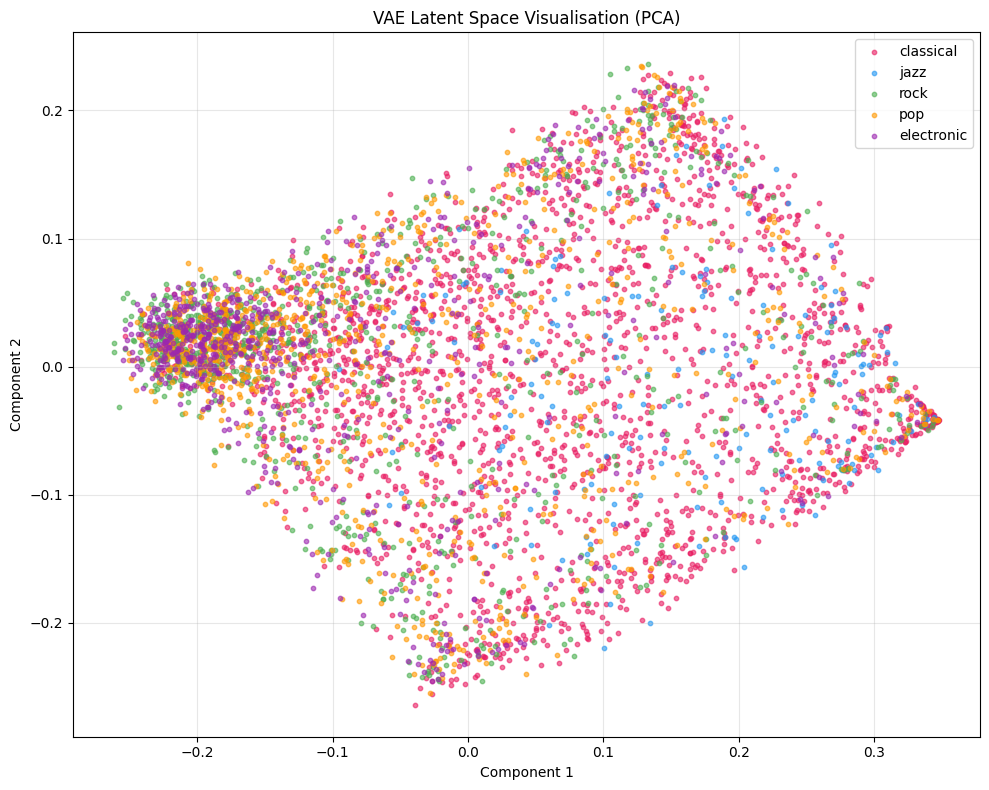

Saved: /content/drive/MyDrive/CSE425/outputs/plots/vae_latent_pca.png


In [24]:
def plot_latent_space(model, dataloader, method="pca", max_samples=2000, device=None):
    """
    Extract latent means (mu) from the VAE encoder for a subset of the dataset
    and project them to 2D using PCA or t-SNE.

    Args:
        model: trained MusicVAE
        dataloader: DataLoader (e.g., vae_val_loader) that yields (tokens, genre)
        method: "pca" or "tsne"
        max_samples: number of samples to use (for speed)
        device: torch device
    """
    if device is None:
        device = next(model.parameters()).device
    model.eval()

    all_mu = []
    all_genres = []
    with torch.no_grad():
        for i, (x, g) in enumerate(dataloader):
            if i * x.size(0) >= max_samples:
                break
            x = x.to(device)
            mu, _ = model.encoder(x)
            all_mu.append(mu.cpu().numpy())
            all_genres.append(g.numpy())

    mu_arr = np.concatenate(all_mu, axis=0)[:max_samples]
    genre_arr = np.concatenate(all_genres, axis=0)[:max_samples]

    # Reduce to 2D
    if method == "pca":
        reducer = PCA(n_components=2, random_state=42)
        latent_2d = reducer.fit_transform(mu_arr)
        title_suffix = "PCA"
    else:
        reducer = TSNE(n_components=2, random_state=42, perplexity=30)
        latent_2d = reducer.fit_transform(mu_arr)
        title_suffix = "t‑SNE"

    # Plot
    plt.figure(figsize=(10, 8))
    colours = ["#E91E63", "#2196F3", "#4CAF50", "#FF9800", "#9C27B0"]
    for i, genre_name in enumerate(GENRES):
        mask = genre_arr == i
        if mask.sum() > 0:
            plt.scatter(latent_2d[mask, 0], latent_2d[mask, 1],
                        c=colours[i], label=genre_name, alpha=0.6, s=10)
    plt.xlabel("Component 1")
    plt.ylabel("Component 2")
    plt.title(f"VAE Latent Space Visualisation ({title_suffix})")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    out_path = PLOTS_DIR / f"vae_latent_{method}.png"
    plt.savefig(out_path, dpi=150)
    plt.show()
    print(f"Saved: {out_path}")

# Usage after training
plot_latent_space(vae_model, vae_val_loader, method="pca", max_samples=5000)

### Baseline Models: Random Note Generator & Markov Chain

Loading training data for baselines...
Loaded 348040 pitch sequences, 15436326 durations
Saved /content/drive/MyDrive/CSE425/outputs/generated_midis/baseline_random/random_sample_01.mid
Saved /content/drive/MyDrive/CSE425/outputs/generated_midis/baseline_random/random_sample_02.mid
Saved /content/drive/MyDrive/CSE425/outputs/generated_midis/baseline_random/random_sample_03.mid
Saved /content/drive/MyDrive/CSE425/outputs/generated_midis/baseline_random/random_sample_04.mid
Saved /content/drive/MyDrive/CSE425/outputs/generated_midis/baseline_random/random_sample_05.mid
Saved /content/drive/MyDrive/CSE425/outputs/generated_midis/baseline_random/random_sample_06.mid
Saved /content/drive/MyDrive/CSE425/outputs/generated_midis/baseline_random/random_sample_07.mid
Saved /content/drive/MyDrive/CSE425/outputs/generated_midis/baseline_random/random_sample_08.mid
Saved /content/drive/MyDrive/CSE425/outputs/generated_midis/baseline_random/random_sample_09.mid
Saved /content/drive/MyDrive/CSE425/ou

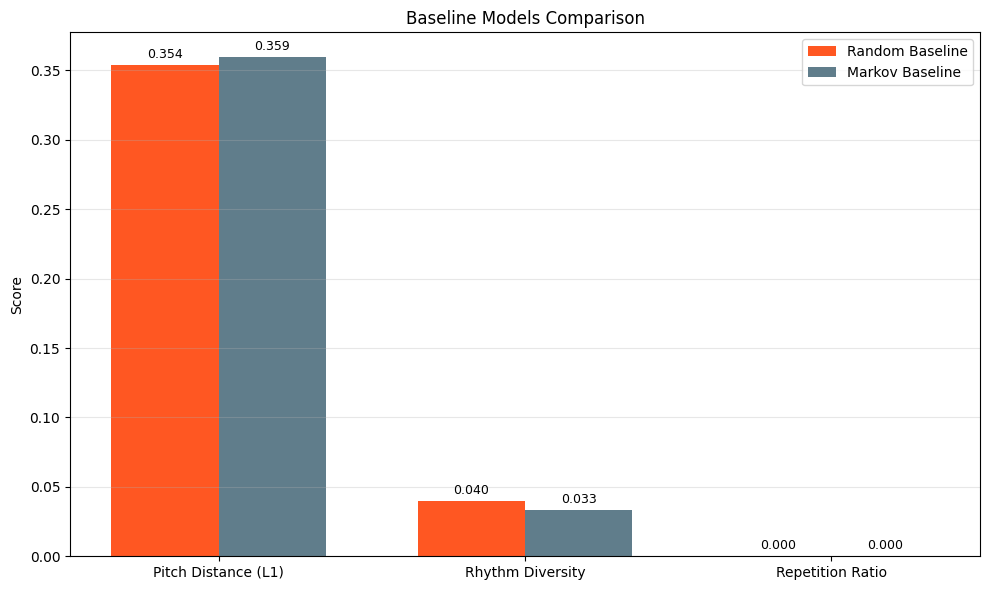

Saved comparison plot to /content/drive/MyDrive/CSE425/outputs/plots/baseline_comparison.png


In [ ]:
# Helper: convert a list of notes to MIDI file
def notes_to_midi(notes, tempo=120, program=0, output_path=None):
    """
    notes: list of (pitch, start_sec, duration_sec)
    """
    pm = pretty_midi.PrettyMIDI(initial_tempo=tempo)
    instrument = pretty_midi.Instrument(program=program)
    for pitch, start, dur in notes:
        note = pretty_midi.Note(velocity=80, pitch=pitch,
                                start=start, end=start + dur)
        instrument.notes.append(note)
    pm.instruments.append(instrument)
    if output_path:
        pm.write(str(output_path))
    return pm

# ------------------------------------------------------------
# 1. Load training data (pitch tokens, durations)
# ------------------------------------------------------------
print("Loading training data for baselines...")
with open(SPLIT_DIR / "train.pkl", "rb") as f:
    train_data = pickle.load(f)   # list of (token_array, genre_label)

# Extract pitch tokens and duration values
train_pitch_sequences = []      # list of lists of pitch token ids (4-91)
train_durations = []            # list of duration steps (from duration tokens)

for tokens, _ in train_data:
    pitch_seq = []
    i = 0
    while i < len(tokens):
        tid = tokens[i]
        if 4 <= tid < 92:   # pitch token
            pitch_seq.append(tid)
            # Look for following duration token
            if i+1 < len(tokens) and DURATION_OFFSET <= tokens[i+1] < DURATION_OFFSET + DURATION_BINS:
                dur_bin = tokens[i+1] - DURATION_OFFSET
                dur_steps = dur_bin + 1
                train_durations.append(dur_steps)
                i += 2
            else:
                train_durations.append(1)   # fallback
                i += 1
        else:
            i += 1
    if pitch_seq:
        train_pitch_sequences.append(pitch_seq)

print(f"Loaded {len(train_pitch_sequences)} pitch sequences, {len(train_durations)} durations")

# ------------------------------------------------------------
# 2. Random Note Generator (Baseline 1)
# ------------------------------------------------------------
def random_note_generator(n_notes=200, max_duration_sec=2.0, tempo=120):
    """
    Generate notes with random pitch (21-108), random start times,
    and random duration from a fixed set.
    """
    pitches = list(range(21, 109))
    durations_sec = [0.25, 0.5, 0.75, 1.0, 1.5, 2.0]
    notes = []
    total_duration = 0
    for _ in range(n_notes):
        pitch = np.random.choice(pitches)
        dur = np.random.choice(durations_sec)
        start = total_duration
        notes.append((pitch, start, dur))
        total_duration += dur
    return notes

# Generate random MIDI files
rand_out_dir = GENERATED_MIDI_DIR / "baseline_random"
rand_out_dir.mkdir(parents=True, exist_ok=True)
random_notes_list = []
for i in range(10):
    notes = random_note_generator(n_notes=150)
    random_notes_list.append(notes)
    out_path = rand_out_dir / f"random_sample_{i+1:02d}.mid"
    notes_to_midi(notes, output_path=out_path)
    print(f"Saved {out_path}")

# ------------------------------------------------------------
# 3. Markov Chain Model (Baseline 2)
# ------------------------------------------------------------
class MarkovChainBaseline:
    def __init__(self, order=1):
        self.order = order
        self.transitions = defaultdict(Counter)  # state -> Counter of next pitch tokens
        self.start_states = []                  # list of starting n-grams
        self.duration_dist = None               # empirical distribution of duration steps

    def train(self, pitch_sequences, durations):
        # Build transition matrix
        for seq in pitch_sequences:
            if len(seq) < self.order + 1:
                continue
            for i in range(len(seq) - self.order):
                state = tuple(seq[i:i+self.order])
                next_tok = seq[i+self.order]
                self.transitions[state][next_tok] += 1
            self.start_states.append(tuple(seq[:self.order]))
        # Duration distribution (normalised counts of duration steps)
        dur_counts = Counter(durations)
        total = sum(dur_counts.values())
        self.duration_dist = {d: c/total for d, c in dur_counts.items()}
        print(f"Markov chain trained: {len(self.transitions)} states, "
              f"{sum(len(v) for v in self.transitions.values())} transitions")
        print(f"Duration distribution: {len(self.duration_dist)} unique values")

    def sample_next_pitch(self, state):
        if state not in self.transitions:
            # Fallback: random pitch among all
            return np.random.randint(4, 92)
        counter = self.transitions[state]
        tokens = list(counter.keys())
        probs = np.array([counter[t] for t in tokens], dtype=float)
        probs /= probs.sum()
        return np.random.choice(tokens, p=probs)

    def sample_duration_steps(self):
        if not self.duration_dist:
            return 1
        durations = list(self.duration_dist.keys())
        probs = list(self.duration_dist.values())
        return np.random.choice(durations, p=probs)

    def generate_notes(self, n_notes=200, tempo=120):
        """
        Generate a list of (pitch, start_sec, duration_sec) notes.
        Notes are placed sequentially; each note's duration is scaled to seconds.
        """
        if not self.start_states:
            raise ValueError("Model not trained")
        # Initial state: random start n-gram
        start_state = list(self.start_states[np.random.randint(len(self.start_states))])
        pitch_seq = start_state.copy()
        # Generate pitch sequence
        for _ in range(n_notes - self.order):
            state = tuple(pitch_seq[-self.order:])
            nxt = self.sample_next_pitch(state)
            pitch_seq.append(nxt)
        # Map pitch tokens to MIDI pitches (token 4 -> MIDI 21, etc.)
        midi_pitches = [ (p - 4 + 21) for p in pitch_seq ]
        # Generate durations
        duration_steps = [self.sample_duration_steps() for _ in range(n_notes)]
        # Convert steps to seconds: one step = ? We need a mapping from steps to seconds.
        # In your tokenisation, a step is 1/16 bar at the file's tempo. Since we don't have tempo,
        # we assume a fixed tempo (120 BPM) and that each step = 0.125 seconds (1/8 second).
        # This is an approximation but sufficient for rhythm diversity.
        step_sec = 60.0 / (tempo * STEPS_PER_BAR)   # STEPS_PER_BAR = 16
        notes = []
        current_time = 0.0
        for pitch, dur_steps in zip(midi_pitches, duration_steps):
            dur_sec = dur_steps * step_sec
            notes.append((pitch, current_time, dur_sec))
            current_time += dur_sec
        return notes

# Train Markov chain
print("\nTraining Markov chain...")
markov = MarkovChainBaseline(order=1)   # first-order as per spec
markov.train(train_pitch_sequences, train_durations)

# Generate Markov MIDI files
markov_out_dir = GENERATED_MIDI_DIR / "baseline_markov"
markov_out_dir.mkdir(parents=True, exist_ok=True)
markov_notes_list = []
for i in range(10):
    notes = markov.generate_notes(n_notes=150)
    markov_notes_list.append(notes)
    out_path = markov_out_dir / f"markov_sample_{i+1:02d}.mid"
    notes_to_midi(notes, output_path=out_path)
    print(f"Saved {out_path}")

# ------------------------------------------------------------
#  Evaluation
# ------------------------------------------------------------
# Find a reference MIDI file (classical preferred, but fallback to any genre)
def get_reference_midi():
    # First try classical folder with both extensions
    classical_dir = RAW_MIDI_DIR / "classical"
    ref_candidates = []
    if classical_dir.exists():
        ref_candidates.extend(classical_dir.glob("*.mid"))
        ref_candidates.extend(classical_dir.glob("*.midi"))
    if ref_candidates:
        return ref_candidates[0]

    # Fallback: any MIDI file from any genre
    for genre in GENRES:
        genre_dir = RAW_MIDI_DIR / genre
        if genre_dir.exists():
            candidates = list(genre_dir.glob("*.mid")) + list(genre_dir.glob("*.midi"))
            if candidates:
                print(f"Warning: No classical MIDI found, using {genre} file: {candidates[0].name}")
                return candidates[0]

    raise FileNotFoundError(f"No MIDI files found in {RAW_MIDI_DIR} or its genre subfolders")

# Reference MIDI (use one classical piece from validation set)
ref_midi_path = get_reference_midi()
print(f"\nReference MIDI: {ref_midi_path}")

def evaluate_midi_files(midi_paths, ref_path):
    results = []
    for path in midi_paths:
        res = {
            "pitch_dist": pitch_class_l1_distance(ref_path, path),
            "rhythm_div": rhythm_diversity_score(path),
            "repetition": repetition_ratio(path)
        }
        results.append(res)
    avg = {
        "pitch_dist": np.mean([r["pitch_dist"] for r in results]),
        "rhythm_div": np.mean([r["rhythm_div"] for r in results]),
        "repetition": np.mean([r["repetition"] for r in results])
    }
    return avg

# Random baseline evaluation
rand_midis = sorted(rand_out_dir.glob("*.mid"))
rand_metrics = evaluate_midi_files(rand_midis, ref_midi_path)
print("\nRandom Baseline Metrics:")
print(f"  Pitch Distance (L1): {rand_metrics['pitch_dist']:.4f} (lower better)")
print(f"  Rhythm Diversity:    {rand_metrics['rhythm_div']:.4f}")
print(f"  Repetition Ratio:    {rand_metrics['repetition']:.4f}")

# Markov baseline evaluation
markov_midis = sorted(markov_out_dir.glob("*.mid"))
markov_metrics = evaluate_midi_files(markov_midis, ref_midi_path)
print("\nMarkov Chain (order=1) Metrics:")
print(f"  Pitch Distance (L1): {markov_metrics['pitch_dist']:.4f}")
print(f"  Rhythm Diversity:    {markov_metrics['rhythm_div']:.4f}")
print(f"  Repetition Ratio:    {markov_metrics['repetition']:.4f}")

# ------------------------------------------------------------
# 5. Simple plot comparison
# ------------------------------------------------------------

metrics_names = ['Pitch Distance (L1)', 'Rhythm Diversity', 'Repetition Ratio']
rand_vals = [rand_metrics['pitch_dist'], rand_metrics['rhythm_div'], rand_metrics['repetition']]
markov_vals = [markov_metrics['pitch_dist'], markov_metrics['rhythm_div'], markov_metrics['repetition']]

x = np.arange(len(metrics_names))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, rand_vals, width, label='Random Baseline', color='#FF5722')
rects2 = ax.bar(x + width/2, markov_vals, width, label='Markov Baseline', color='#607D8B')

ax.set_ylabel('Score')
ax.set_title('Baseline Models Comparison')
ax.set_xticks(x)
ax.set_xticklabels(metrics_names)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# Add values on bars
for rects in [rects1, rects2]:
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(rect.get_x() + rect.get_width()/2, height),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'baseline_comparison.png', dpi=150)
plt.show()
print(f"Saved comparison plot to {PLOTS_DIR / 'baseline_comparison.png'}")

### Evaluation

In [39]:
# ============================================================
# Evaluation of Generated MIDI Files (AE & VAE) – Per Genre
# ============================================================


# ------------------------------
# 1. Paths to generated MIDI files
# ------------------------------
gen_dir = GENERATED_MIDI_DIR

# AE files (classical only)
ae_files = sorted(gen_dir.glob("ae_sample_*.mid")) + sorted(gen_dir.glob("ae_sample_*.midi"))
ae_files = sorted(set(ae_files))

# VAE files (pattern: genre_sample_*.mid / .midi) – manual filtering
vae_files = []
for f in gen_dir.iterdir():
    if (f.suffix in ['.mid', '.midi'] and
        '_sample_' in f.stem and
        not f.stem.startswith('ae_sample_')):
        vae_files.append(f)
vae_files = sorted(set(vae_files))
print(f"Found {len(ae_files)} AE files, {len(vae_files)} VAE files")

# ------------------------------
# 2. Reference MIDI (classical)
# ------------------------------
ref_candidates = list(RAW_MIDI_DIR.glob("classical/*.mid")) + list(RAW_MIDI_DIR.glob("classical/*.midi"))
if ref_candidates:
    ref_midi = ref_candidates[0]
    print(f"Using reference MIDI: {ref_midi}")
else:
    raise FileNotFoundError(f"No classical MIDI file found in {RAW_MIDI_DIR / 'classical'}")

# ------------------------------
# 3. Extract genre from VAE filename
# ------------------------------
def extract_genre(filename):
    # filename like "classical_sample_01.mid"
    match = re.match(r"([a-z]+)_sample_", filename.stem)
    if match:
        return match.group(1).capitalize()
    return "unknown"

# ------------------------------
# 4. Compute metrics
# ------------------------------
results = []

# AE samples (classical only)
for f in ae_files:
    try:
        results.append({
            "Model": "AE",
            "Genre": "Classical",
            "File": f.name,
            "Pitch Dist": pitch_class_l1_distance(ref_midi, f),
            "Rhythm Div": rhythm_diversity_score(f),
            "Repetition": repetition_ratio(f)
        })
    except Exception as e:
        print(f"Error processing {f.name}: {e}")

# VAE samples (all genres)
for f in vae_files:
    genre = extract_genre(f)
    try:
        results.append({
            "Model": "VAE",
            "Genre": genre,
            "File": f.name,
            "Pitch Dist": pitch_class_l1_distance(ref_midi, f),
            "Rhythm Div": rhythm_diversity_score(f),
            "Repetition": repetition_ratio(f)
        })
    except Exception as e:
        print(f"Error processing {f.name}: {e}")

if not results:
    raise RuntimeError("No valid MIDI files found for evaluation.")

# ------------------------------
# 5. Compute averages per model and per genre
# ------------------------------
df = pd.DataFrame(results)

print("\n" + "="*80)
print("EVALUATION METRICS – PER FILE")
print("="*80)
print(df.to_string(index=False))

# Average per model (overall)
print("\n" + "-"*80)
print("AVERAGE PER MODEL (ALL GENRES)")
print("-"*80)
avg_ae = df[df["Model"]=="AE"][["Pitch Dist", "Rhythm Div", "Repetition"]].mean()
avg_vae = df[df["Model"]=="VAE"][["Pitch Dist", "Rhythm Div", "Repetition"]].mean()
print(f"AE  - Pitch Dist: {avg_ae['Pitch Dist']:.4f} | Rhythm Div: {avg_ae['Rhythm Div']:.4f} | Repetition: {avg_ae['Repetition']:.4f}")
print(f"VAE - Pitch Dist: {avg_vae['Pitch Dist']:.4f} | Rhythm Div: {avg_vae['Rhythm Div']:.4f} | Repetition: {avg_vae['Repetition']:.4f}")

# Per genre for VAE
print("\n" + "-"*80)
print("VAE METRICS PER GENRE")
print("-"*80)
vae_genre_avg = df[df["Model"]=="VAE"].groupby("Genre")[["Pitch Dist", "Rhythm Div", "Repetition"]].mean()
print(vae_genre_avg.to_string())

# ------------------------------
# 6. Validation losses (optional)
# ------------------------------
ae_val_loss = None
vae_val_loss = None
if 'ae_val_losses' in globals() and ae_val_losses:
    ae_val_loss = ae_val_losses[-1]
if 'vae_val_losses' in globals() and vae_val_losses:
    vae_val_loss = vae_val_losses[-1]

if ae_val_loss is None:
    ae_val_loss = input("Enter AE final validation loss (or press Enter to skip): ") or "N/A"
if vae_val_loss is None:
    vae_val_loss = input("Enter VAE final validation loss (or press Enter to skip): ") or "N/A"

# ------------------------------
# 7. Report table (AE vs VAE overall)
# ------------------------------
print("\n" + "-"*80)
print("REPORT TABLE (AE vs VAE Overall)")
print("-"*80)
print(f"{'Model':<20} {'Loss':<10} {'Pitch Dist':<12} {'Rhythm Div':<12} {'Repetition':<12}")
print(f"{'AE':<20} {str(ae_val_loss)[:10]:<10} {avg_ae['Pitch Dist']:<12.4f} {avg_ae['Rhythm Div']:<12.4f} {avg_ae['Repetition']:<12.4f}")
print(f"{'VAE':<20} {str(vae_val_loss)[:10]:<10} {avg_vae['Pitch Dist']:<12.4f} {avg_vae['Rhythm Div']:<12.4f} {avg_vae['Repetition']:<12.4f}")

print("\nNote: Lower Pitch Dist is better; higher Rhythm Div and moderate Repetition (0.1–0.5) are desirable.")

Found 5 AE files, 10 VAE files
Using reference MIDI: /content/drive/MyDrive/CSE425/data/raw_midi/classical/MIDI-Unprocessed_07_R1_2008_01-04_ORIG_MID--AUDIO_07_R1_2008_wav--3.midi

EVALUATION METRICS – PER FILE
Model      Genre                     File  Pitch Dist  Rhythm Div  Repetition
   AE  Classical         ae_sample_01.mid    0.872196    0.259259    0.000000
   AE  Classical         ae_sample_02.mid    0.765696    0.200000    0.000000
   AE  Classical         ae_sample_03.mid    1.147095    0.205128    0.027778
   AE  Classical         ae_sample_04.mid    1.060566    0.193548    0.000000
   AE  Classical         ae_sample_05.mid    1.072117    0.100000    0.000000
  VAE  Classical  classical_sample_01.mid    1.815230    0.083333    0.222222
  VAE  Classical  classical_sample_02.mid    1.815230    0.083333    0.222222
  VAE Electronic electronic_sample_01.mid    1.462402    0.017857    0.094340
  VAE Electronic electronic_sample_02.mid    1.462402    0.017857    0.094340
  VAE    